# Q4_0 vs Q8_0: context 128 vs full Llama 3 context

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/papo1011/DetectLlama/blob/main/notebooks/q4_q8_context_benchmark.ipynb)

This notebook compares the two Llama 3 8B **base** GGUF quantizations relevant
to DetectLlama:

- Q4_0, the best model in the first benchmark;
- Q8_0, a high-fidelity quantized reference;
- context 128; and
- context 8192, the original Llama 3 maximum context.

The default budget is deliberately moderate: 80 calibration texts and 160
held-out evaluation texts. Each human text is paired with one AI text answering
the same prompt and belonging to the same token-length band. The exact same
pairs are used for all four model/context configurations.

Thresholds are fitted independently for every model/context configuration using
the training split only. Final metrics use the test split only. Clustered,
stratified bootstrap intervals resample prompt pairs, propagate threshold
uncertainty, and preserve the paired experimental design.

With 80 held-out texts per class, the worst-case 95% half-width for balanced
accuracy is approximately 7.8 percentage points. This is a substantially more
informative exploratory benchmark than the original 32-text evaluation, but it
is not a universal validation of AI detection.

**Resource warning:** 240 texts × 4 configurations means 960 document scores.
Q8_0 is 8.54 GB. With `logits_all=True`, context 8192 also reserves roughly
4.2 GB of host RAM for Llama 3's 128k-vocabulary score matrix. A GPU runtime
with a high-RAM Colab session is strongly recommended. Checkpoints are written
repeatedly, and the sample-size
constants can be reduced for a smoke test or increased for a stronger study.


In [1]:
# Colab setup. CUDA compilation can take several minutes.
import os
import subprocess
import sys

base_packages = ["duckdb>=1.1", "huggingface_hub>=0.27"]
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", *base_packages]
)

has_nvidia = subprocess.run(
    ["bash", "-lc", "command -v nvidia-smi >/dev/null && nvidia-smi -L >/dev/null"],
    check=False,
).returncode == 0

llama_env = os.environ.copy()
if has_nvidia:
    llama_env["CMAKE_ARGS"] = "-DGGML_CUDA=on"
    llama_env["FORCE_CMAKE"] = "1"

llama_install = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "--no-cache-dir",
]
if has_nvidia:
    llama_install.extend(["--no-binary", "llama-cpp-python"])
llama_install.append("llama-cpp-python")
subprocess.check_call(llama_install, env=llama_env)
print("Installed llama-cpp-python with", "CUDA" if has_nvidia else "CPU", "support")


Installed llama-cpp-python with CUDA support


In [2]:
import gc
import hashlib
import json
import math
import platform
import shutil
import time
import warnings
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from huggingface_hub import HfApi, hf_hub_download
from llama_cpp import Llama
from tqdm.auto import tqdm

try:
    import torch
except ImportError:
    torch = None

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Python:", platform.python_version())
print("CUDA visible:", bool(torch is not None and torch.cuda.is_available()))
if torch is not None and torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
CUDA visible: False


## Preregistered configuration

The primary unit of independence is a prompt pair, not an individual generated
variant. For each selected prompt the notebook retains one human answer and one
AI answer from the same length band. This avoids treating the six correlated AI
variants associated with one prompt as six independent observations.

There are four primary paired comparisons:

1. Q4_0 versus Q8_0 at context 128;
2. Q4_0 versus Q8_0 at context 8192;
3. context 8192 versus 128 for Q4_0; and
4. context 8192 versus 128 for Q8_0.

The comparison intervals use a Bonferroni-adjusted family-wise error rate of
5%. Ordinary per-configuration metrics retain 95% intervals.


In [3]:
SEED = 20260731
DATASET_ID = "polsci/ghostbuster-essay-cleaned"
DATASET_LICENSE = "CC BY 3.0"
CALIBRATION_SPLIT = "train"
EVALUATION_SPLIT = "test"

# Defaults chosen to keep the run feasible: 40 calibration and 80 evaluation
# prompt pairs, with two documents (human + AI) in every pair.
CALIBRATION_TEXTS = 80
EVALUATION_TEXTS = 160
MIN_CALIBRATION_PAIRS = 30
MIN_EVALUATION_PAIRS = 60

MIN_TEXT_TOKENS = 150
MAX_TEXT_TOKENS = 5_000
TOKEN_LENGTH_BANDS = [
    ("150–399", 150, 399),
    ("400–699", 400, 699),
    ("700–1024", 700, 1_024),
    ("1025–5000", 1_025, 5_000),
]

CONTEXT_LENGTHS = [128, 8_192]
FULL_LLAMA3_CONTEXT = 8_192
MAX_WINDOW_OVERLAP = 256
LOGIT_BLOCK_ROWS = 16
MOMENT_DTYPE = np.float32
N_GPU_LAYERS = -1
N_THREADS = max(1, (os.cpu_count() or 2) - 1)
N_UBATCH = 128
CHECKPOINT_EVERY_DOCUMENTS = 5
BOOTSTRAP_REPEATS = 2_000
PRIMARY_COMPARISONS = 4
COMPARISON_CI_LEVEL = 1.0 - 0.05 / PRIMARY_COMPARISONS
RESUME_FROM_CHECKPOINTS = True
DELETE_MODEL_AFTER_RUN = True
DELETE_DATASET_AFTER_SAMPLING = True

assert CALIBRATION_TEXTS % 2 == 0
assert EVALUATION_TEXTS % 2 == 0
assert CONTEXT_LENGTHS == [128, FULL_LLAMA3_CONTEXT]

CALIBRATION_PAIRS = CALIBRATION_TEXTS // 2
EVALUATION_PAIRS = EVALUATION_TEXTS // 2

# Worst-case normal-approximation half-width for balanced accuracy when both
# class recalls use n paired examples. Reported intervals below use bootstrap.
worst_case_ba_half_width = 1.96 * math.sqrt(0.125 / EVALUATION_PAIRS)
print(f"Default held-out BA half-width (worst-case approximation): ±{worst_case_ba_half_width:.1%}")
print(f"Multiplicity-adjusted comparison CI: {COMPARISON_CI_LEVEL:.2%}")

IN_COLAB = "google.colab" in sys.modules
OUTPUT_ROOT = Path("/content/detectllama_q4_q8" if IN_COLAB else "detectllama_q4_q8")
MODEL_DIR = Path("/content/detectllama_models" if IN_COLAB else "detectllama_models")
DATASET_DIR = Path("/content/detectllama_dataset" if IN_COLAB else "detectllama_dataset")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)


Default held-out BA half-width (worst-case approximation): ±7.7%
Multiplicity-adjusted comparison CI: 98.75%


In [4]:
@dataclass(frozen=True)
class ModelSpec:
    model_id: str
    precision: str
    repo_id: str
    filename: str
    size_gb: float

    @property
    def label(self):
        return f"Llama 3 8B {self.precision}"


BASE_REPO = "QuantFactory/Meta-Llama-3-8B-GGUF"
MODELS = [
    ModelSpec(
        "base_q4_0",
        "Q4_0",
        BASE_REPO,
        "Meta-Llama-3-8B.Q4_0.gguf",
        4.66,
    ),
    ModelSpec(
        "base_q8_0",
        "Q8_0",
        BASE_REPO,
        "Meta-Llama-3-8B.Q8_0.gguf",
        8.54,
    ),
]
display(pd.DataFrame([asdict(model) for model in MODELS]))


,model_id,precision,repo_id,filename,size_gb
0,base_q4_0,Q4_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_0.gguf,4.66
1,base_q8_0,Q8_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q8_0.gguf,8.54


## Dataset and prompt-paired sampling

Ghostbuster label 6 is human; only label 0 (Claude) and label 1 (GPT) are
retained as AI sources. Labels 2–5 are excluded.
Calibration uses only `train` and evaluation uses only `test`. The dataset
revision is pinned before any files are downloaded.

The Q4_0 vocabulary is loaded first so all length decisions use the exact Llama
tokenizer. A pair is eligible only when its human answer and at least one AI
answer fall in the same predefined token-length band. One AI source is selected
per prompt while greedily balancing source strategies.


In [5]:
dataset_info = HfApi().dataset_info(DATASET_ID)
DATASET_REVISION = dataset_info.sha
RUN_ID = (
    f"q4-q8_ctx128-8192_{DATASET_REVISION[:8]}_seed{SEED}_"
    f"cal{CALIBRATION_TEXTS}_eval{EVALUATION_TEXTS}"
)
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Pinned dataset revision:", DATASET_REVISION)
print("Run directory:", OUTPUT_DIR.resolve())

DATASET_FILES = {
    "train": "data/train-00000-of-00001.parquet",
    "test": "data/test-00000-of-00001.parquet",
}
downloaded_dataset_files = set()
staged_model_paths = set()


def normalized_hash(value):
    normalized = " ".join(str(value).split()).casefold()
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


def stable_order_key(value, seed):
    return hashlib.sha256(f"{seed}:{value}".encode("utf-8")).hexdigest()


def local_parquet(split):
    filename = DATASET_FILES[split]
    target = DATASET_DIR / filename
    existed_before = target.exists()
    path = Path(
        hf_hub_download(
            repo_id=DATASET_ID,
            repo_type="dataset",
            filename=filename,
            revision=DATASET_REVISION,
            local_dir=DATASET_DIR,
        )
    )
    if not existed_before:
        downloaded_dataset_files.add(path)
    return path


def load_split(split):
    connection = duckdb.connect()
    try:
        return connection.execute(
            """
            SELECT
                trim(CAST(text AS VARCHAR)) AS text,
                CAST(label AS INTEGER) AS source_label,
                CAST(filename AS VARCHAR) AS filename,
                CAST(prompt AS VARCHAR) AS prompt
            FROM read_parquet(?)
            WHERE text IS NOT NULL
              AND length(trim(CAST(text AS VARCHAR))) > 0
              AND CAST(label AS INTEGER) IN (0, 1, 6)
            """,
            [str(local_parquet(split))],
        ).df()
    finally:
        connection.close()


def token_length_band(token_count):
    for band, low, high in TOKEN_LENGTH_BANDS:
        if low <= token_count <= high:
            return band
    return None


sample_cache = OUTPUT_DIR / "paired_samples.csv"
tokenizer_path = None
if sample_cache.exists() and RESUME_FROM_CHECKPOINTS:
    samples = pd.read_csv(sample_cache)
    print("Loaded paired sample cache:", sample_cache)
else:
    tokenizer_model = MODELS[0]
    tokenizer_target = MODEL_DIR / tokenizer_model.filename
    tokenizer_existed = tokenizer_target.exists()
    tokenizer_path = Path(
        hf_hub_download(
            repo_id=tokenizer_model.repo_id,
            filename=tokenizer_model.filename,
            local_dir=MODEL_DIR,
        )
    )
    if not tokenizer_existed:
        staged_model_paths.add(tokenizer_path)

    tokenizer = Llama(
        model_path=str(tokenizer_path),
        vocab_only=True,
        n_ctx=16,
        n_gpu_layers=0,
        use_mmap=True,
        verbose=False,
    )

    def prepare_split(split):
        frame = load_split(split)
        frame["text_hash"] = frame.text.map(normalized_hash)
        frame["pair_id"] = [
            normalized_hash(f"{filename}\n{prompt}")
            for filename, prompt in zip(frame.filename, frame.prompt)
        ]
        frame = frame.drop_duplicates("text_hash").copy()
        frame["original_token_count"] = [
            len(
                tokenizer.tokenize(
                    str(text).encode("utf-8"),
                    add_bos=True,
                    special=False,
                )
            ) - 1
            for text in tqdm(frame.text, desc=f"Tokenizing {split}")
        ]
        frame["length_band"] = frame.original_token_count.map(token_length_band)
        return frame.dropna(subset=["length_band"]).copy()

    calibration_candidates = prepare_split(CALIBRATION_SPLIT)
    evaluation_candidates = prepare_split(EVALUATION_SPLIT)
    tokenizer.close()
    del tokenizer
    gc.collect()

    def construct_prompt_pairs(frame, seed):
        source_counts = Counter()
        documents = []
        pair_rows = []
        pair_ids = sorted(
            frame.pair_id.unique(),
            key=lambda pair_id: stable_order_key(pair_id, seed),
        )
        for pair_id in pair_ids:
            group = frame[frame.pair_id == pair_id]
            humans = group[group.source_label == 6]
            if humans.empty:
                continue
            human = humans.sort_values("text_hash").iloc[0]
            ai_candidates = group[
                (group.source_label.isin([0, 1]))
                & (group.length_band == human.length_band)
            ].copy()
            if ai_candidates.empty:
                continue
            ai_candidates["selection_key"] = [
                (
                    source_counts[int(source)],
                    stable_order_key(text_hash, seed),
                )
                for source, text_hash in zip(
                    ai_candidates.source_label,
                    ai_candidates.text_hash,
                )
            ]
            ai = ai_candidates.sort_values("selection_key").iloc[0]
            source_counts[int(ai.source_label)] += 1

            pair_rows.append(
                {
                    "pair_id": pair_id,
                    "length_band": human.length_band,
                    "ai_source_label": int(ai.source_label),
                }
            )
            for label, row in ((0, human), (1, ai)):
                documents.append(
                    {
                        "pair_id": pair_id,
                        "label": label,
                        "source_label": int(row.source_label),
                        "text": row.text,
                        "text_hash": row.text_hash,
                        "filename": row.filename,
                        "original_token_count": int(row.original_token_count),
                        "length_band": row.length_band,
                    }
                )
        return pd.DataFrame(documents), pd.DataFrame(pair_rows)

    def select_pairs(pair_table, target_pairs, minimum_pairs, seed):
        bands = [band for band, _, _ in TOKEN_LENGTH_BANDS]
        availability = pair_table.length_band.value_counts().reindex(bands, fill_value=0)
        actual_target = min(target_pairs, int(availability.sum()))
        if actual_target < minimum_pairs:
            raise RuntimeError(
                f"Only {actual_target} eligible prompt pairs; need at least {minimum_pairs}."
            )
        if actual_target < target_pairs:
            warnings.warn(
                f"Using {actual_target} pairs instead of requested {target_pairs}; "
                "the dataset has fewer eligible same-band prompt pairs."
            )

        base, remainder = divmod(actual_target, len(bands))
        quotas = {
            band: min(base + int(i < remainder), int(availability[band]))
            for i, band in enumerate(bands)
        }
        deficit = actual_target - sum(quotas.values())
        while deficit:
            changed = False
            for band in bands:
                if quotas[band] < int(availability[band]):
                    quotas[band] += 1
                    deficit -= 1
                    changed = True
                    if deficit == 0:
                        break
            if not changed:
                raise RuntimeError("Could not allocate the requested pair quota")

        selected = []
        rng = np.random.default_rng(seed)
        for band, quota in quotas.items():
            candidates = pair_table[pair_table.length_band == band].pair_id.to_numpy()
            selected.extend(rng.choice(candidates, size=quota, replace=False).tolist())
        return set(selected), quotas

    cal_documents, cal_pairs = construct_prompt_pairs(calibration_candidates, SEED)
    eval_documents, eval_pairs = construct_prompt_pairs(evaluation_candidates, SEED + 1)
    cal_selected, cal_quotas = select_pairs(
        cal_pairs,
        CALIBRATION_PAIRS,
        MIN_CALIBRATION_PAIRS,
        SEED,
    )
    eval_selected, eval_quotas = select_pairs(
        eval_pairs,
        EVALUATION_PAIRS,
        MIN_EVALUATION_PAIRS,
        SEED + 1,
    )

    calibration_df = cal_documents[cal_documents.pair_id.isin(cal_selected)].copy()
    evaluation_df = eval_documents[eval_documents.pair_id.isin(eval_selected)].copy()
    calibration_df["partition"] = "calibration"
    evaluation_df["partition"] = "evaluation"
    samples = pd.concat([calibration_df, evaluation_df], ignore_index=True)
    samples["sample_id"] = [
        f"{partition}:{pair_id[:12]}:{label}"
        for partition, pair_id, label in zip(
            samples.partition,
            samples.pair_id,
            samples.label,
        )
    ]
    samples.to_csv(sample_cache, index=False)
    print("Saved paired samples:", sample_cache)

required_columns = {
    "sample_id", "pair_id", "partition", "label", "source_label", "text",
    "text_hash", "original_token_count", "length_band",
}
if not required_columns.issubset(samples.columns):
    raise RuntimeError(f"Stale or invalid sample cache: {sample_cache}")

for partition, minimum_pairs in (
    ("calibration", MIN_CALIBRATION_PAIRS),
    ("evaluation", MIN_EVALUATION_PAIRS),
):
    subset = samples[samples.partition == partition]
    counts = subset.label.value_counts().to_dict()
    pair_count = subset.pair_id.nunique()
    assert counts == {0: pair_count, 1: pair_count}
    assert pair_count >= minimum_pairs
    assert (subset.groupby("pair_id").length_band.nunique() == 1).all()

cal_hashes = set(samples[samples.partition == "calibration"].pair_id)
eval_hashes = set(samples[samples.partition == "evaluation"].pair_id)
assert cal_hashes.isdisjoint(eval_hashes)
assert samples.original_token_count.between(MIN_TEXT_TOKENS, MAX_TEXT_TOKENS).all()
assert set(samples.source_label.unique()).issubset({0, 1, 6})
for partition in ("calibration", "evaluation"):
    selected_ai_sources = set(
        samples[(samples.partition == partition) & (samples.label == 1)]
        .source_label.unique()
    )
    assert selected_ai_sources == {0, 1}, (
        f"{partition} must contain both Claude (0) and GPT (1), got "
        f"{selected_ai_sources}"
    )

display(
    samples.groupby(["partition", "label", "length_band"])
    .agg(
        texts=("sample_id", "size"),
        min_tokens=("original_token_count", "min"),
        median_tokens=("original_token_count", "median"),
        max_tokens=("original_token_count", "max"),
    )
)
display(
    samples[samples.label == 1]
    .groupby(["partition", "source_label"])
    .size()
    .rename("selected_ai_texts")
    .reset_index()
)

realized_eval_pairs = samples[samples.partition == "evaluation"].pair_id.nunique()
realized_half_width = 1.96 * math.sqrt(0.125 / realized_eval_pairs)
print(
    f"Realized evaluation: {realized_eval_pairs} prompt pairs, "
    f"worst-case BA half-width ≈ ±{realized_half_width:.1%}"
)

if DELETE_DATASET_AFTER_SAMPLING:
    for path in sorted(downloaded_dataset_files):
        if path.exists():
            path.unlink()
    print(f"Deleted {len(downloaded_dataset_files)} staged Parquet file(s)")


Pinned dataset revision: 953b44b7b1d8278a5c955ba0649846900cab4285
Run directory: /content/detectllama_q4_q8/q4-q8_ctx128-8192_953b44b7_seed20260731_cal80_eval160


Meta-Llama-3-8B.Q4_0.gguf: reconstructing file:   0%|          |  0.00B / 4.66GB            

Meta-Llama-3-8B.Q4_0.gguf: downloading bytes:           |  0.00B            

llama_context: n_ctx_seq (256) > n_ctx_train (0) -- possible training context overflow


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 8.83MB            

...

Tokenizing test:   0%|          | 0/900 [00:00<?, ?it/s]

Saved paired samples: /content/detectllama_q4_q8/q4-q8_ctx128-8192_953b44b7_seed20260731_cal80_eval160/paired_samples.csv


texts  min_tokens  median_tokens  max_tokens
partition   label length_band                                              
calibration 0     1025–5000       10        1167         1625.0        2387
                  150–399         10         206          289.5         391
                  400–699         10         406          538.0         696
                  700–1024        10         720          783.0         978
            1     1025–5000       10        1058         1133.5        2144
                  150–399         10         323          371.5         399
                  400–699         10         442          552.5         602
                  700–1024        10         719          797.0        1010
evaluation  0     1025–5000       24        1029         1804.0        4188
                  150–399          6         207          326.0         372
                  400–699         25         404          455.0         687
                  700–1024        25         702          792.0         949
            1     1025–5000       24        1032         1119.5        1827
                  150–399          6         274          343.0         384
                  400–699         25         458          613.0         692
                  700–1024        25         709          804.0        1024

,partition,source_label,selected_ai_texts
0,calibration,0,12
1,calibration,1,28
2,evaluation,0,25
3,evaluation,1,55


Realized evaluation: 80 prompt pairs, worst-case BA half-width ≈ ±7.7%
Deleted 2 staged Parquet file(s)


## Analytic FastDetect scorer

For every observed token, the scorer accumulates the observed log-probability,
the expected log-probability under the model distribution, and its variance.
Every target token is scored exactly once. Documents longer than the active
context are processed in overlapping windows; document statistics are rebuilt
from global sums rather than averaged window scores.


In [6]:
def accumulate_token_moments(logits, labels, block_rows=LOGIT_BLOCK_ROWS):
    labels = np.asarray(labels, dtype=np.int64)
    if logits.shape[0] != labels.shape[0]:
        raise ValueError("Logit and label row counts differ")

    observed_sum = 0.0
    expected_sum = 0.0
    variance_sum = 0.0
    for start in range(0, len(labels), block_rows):
        stop = min(len(labels), start + block_rows)
        block = np.asarray(logits[start:stop], dtype=MOMENT_DTYPE)
        if not np.isfinite(block).all():
            raise FloatingPointError("Non-finite logits")
        row_max = block.max(axis=1, keepdims=True)
        shifted = block - row_max
        exp_shifted = np.exp(shifted)
        normalizer = exp_shifted.sum(axis=1, dtype=np.float64)
        log_normalizer = np.log(normalizer)
        local_labels = labels[start:stop]
        observed = (
            shifted[np.arange(stop - start), local_labels].astype(np.float64)
            - log_normalizer
        )
        mean_shifted = (
            (exp_shifted * shifted).sum(axis=1, dtype=np.float64) / normalizer
        )
        mean_shifted_square = (
            (exp_shifted * shifted * shifted).sum(axis=1, dtype=np.float64)
            / normalizer
        )
        variance = np.maximum(
            0.0,
            mean_shifted_square - mean_shifted * mean_shifted,
        )
        observed_sum += observed.sum(dtype=np.float64)
        expected_sum += (mean_shifted - log_normalizer).sum(dtype=np.float64)
        variance_sum += variance.sum(dtype=np.float64)
    return observed_sum, expected_sum, variance_sum


class FastDetectScorer:
    def __init__(self, llm, max_overlap=MAX_WINDOW_OVERLAP):
        self.llm = llm
        self.max_overlap = max_overlap

    def tokenize(self, text):
        return self.llm.tokenize(
            str(text).encode("utf-8"),
            add_bos=True,
            special=False,
        )

    def score_tokens(self, tokens, context_length):
        if len(tokens) < 2:
            raise ValueError("At least one text token is required")
        if context_length < 3 or context_length > self.llm.n_ctx():
            raise ValueError(
                f"context_length must be in [3, {self.llm.n_ctx()}]"
            )

        started = time.perf_counter()
        bos_token = self.llm.token_bos()
        has_bos = bos_token >= 0 and tokens[0] == bos_token
        content_floor = 1 if has_bos else 0
        overlap = min(
            self.max_overlap,
            max(1, (context_length - 1) // 4),
            context_length - 2,
        )
        observed_sum = expected_sum = variance_sum = 0.0
        target_start = 1
        windows = 0
        scored_total = 0

        while target_start < len(tokens):
            first_window = target_start == 1
            prefix_tokens = 0 if first_window or not has_bos else 1
            context_start = (
                0
                if first_window
                else max(content_floor, target_start - overlap)
            )
            content_capacity = context_length - prefix_tokens
            window_end = min(len(tokens), context_start + content_capacity)
            scored_tokens = window_end - target_start
            if scored_tokens <= 0:
                raise RuntimeError("Windowed scorer could not advance")

            window_tokens = []
            if prefix_tokens:
                window_tokens.append(bos_token)
            window_tokens.extend(tokens[context_start:window_end])
            local_target_start = (
                1
                if first_window
                else prefix_tokens + target_start - context_start
            )
            first_predictor = local_target_start - 1

            self.llm.reset()
            self.llm.eval(window_tokens)
            logits = self.llm.scores[
                first_predictor : first_predictor + scored_tokens
            ]
            labels = tokens[target_start:window_end]
            observed, expected, variance = accumulate_token_moments(logits, labels)
            observed_sum += observed
            expected_sum += expected
            variance_sum += variance
            target_start = window_end
            windows += 1
            scored_total += scored_tokens

        if scored_total != len(tokens) - 1:
            raise RuntimeError("Incomplete token coverage")
        if not np.isfinite(variance_sum) or variance_sum <= 1e-9:
            raise FloatingPointError("Invalid discrepancy variance")
        score = (observed_sum - expected_sum) / math.sqrt(variance_sum)
        if not np.isfinite(score):
            raise FloatingPointError("Non-finite discrepancy")
        return {
            "score": float(score),
            "token_count": len(tokens) - 1,
            "scored_token_count": scored_total,
            "complete_coverage": True,
            "windows": windows,
            "context_overlap": overlap if windows > 1 else 0,
            "elapsed_seconds": time.perf_counter() - started,
        }


# Numerical unit test independent of llama.cpp.
toy_logits = np.array([[0.1, 1.2, -0.4], [2.0, 0.0, -1.0]], dtype=np.float32)
toy_labels = np.array([1, 0])
toy_sums = accumulate_token_moments(toy_logits, toy_labels, block_rows=1)
assert all(np.isfinite(toy_sums))
print("Analytic moment test passed:", toy_sums)


Analytic moment test passed: (np.float64(-0.5982249649734991), np.float64(-1.4016989490817617), np.float64(1.106806087587156))


## Scoring with resumable checkpoints

Both GGUFs are loaded with an 8192-token context. The notebook checks the GGUF
training-context metadata and the active llama.cpp context before scoring.
Context 128 is implemented by the same exact windowing rule used by
DetectLlama; context 8192 scores every selected passage in one window because
passages are limited to 5000 tokens.


In [7]:
score_columns = [
    "model_id", "precision", "model_label", "sample_id", "pair_id",
    "partition", "label", "source_label", "length_band",
    "original_token_count", "context_length", "score", "token_count",
    "scored_token_count", "complete_coverage", "windows",
    "context_overlap", "elapsed_seconds", "error",
]


def checkpoint_path(model):
    return OUTPUT_DIR / f"scores_{model.model_id}_ctx128-8192.csv"


def save_checkpoint(frame, path):
    temporary = path.with_suffix(".tmp.csv")
    frame[score_columns].to_csv(temporary, index=False)
    temporary.replace(path)


def merge_score_rows(existing, new_rows):
    fresh = pd.DataFrame(new_rows, columns=score_columns)
    if existing.empty:
        combined = fresh
    elif fresh.empty:
        combined = existing.copy()
    else:
        combined = pd.concat([existing, fresh], ignore_index=True)
    return combined.drop_duplicates(
        ["sample_id", "context_length"],
        keep="last",
    )


def score_model(model):
    checkpoint = checkpoint_path(model)
    if checkpoint.exists() and RESUME_FROM_CHECKPOINTS:
        existing = pd.read_csv(checkpoint)
        if set(score_columns).issubset(existing.columns):
            existing = existing[score_columns].copy()
        else:
            warnings.warn(f"Ignoring stale checkpoint: {checkpoint}")
            existing = pd.DataFrame(columns=score_columns)
    else:
        existing = pd.DataFrame(columns=score_columns)

    expected = {
        (sample_id, context)
        for sample_id in samples.sample_id
        for context in CONTEXT_LENGTHS
    }
    valid_existing = existing[
        existing.score.notna()
        & existing.error.fillna("").eq("")
    ]
    completed = set(zip(valid_existing.sample_id, valid_existing.context_length))
    if completed == expected:
        print("Using complete checkpoint:", checkpoint)
        return existing

    free_gb = shutil.disk_usage(MODEL_DIR).free / 1e9
    if free_gb < model.size_gb + 1.0:
        raise RuntimeError(
            f"{model.label} needs {model.size_gb:.1f} GB plus headroom; "
            f"only {free_gb:.1f} GB is free."
        )

    target = MODEL_DIR / model.filename
    existed_before = target.exists()
    model_path = None
    model_path = Path(
        hf_hub_download(
            repo_id=model.repo_id,
            filename=model.filename,
            local_dir=MODEL_DIR,
        )
    )
    if not existed_before:
        staged_model_paths.add(model_path)

    effective_gpu_layers = (
        N_GPU_LAYERS
        if torch is not None and torch.cuda.is_available()
        else 0
    )
    llm = None
    try:
        llm = Llama(
            model_path=str(model_path),
            n_ctx=FULL_LLAMA3_CONTEXT,
            n_batch=512,
            n_ubatch=N_UBATCH,
            n_threads=N_THREADS,
            n_gpu_layers=effective_gpu_layers,
            logits_all=True,
            embedding=False,
            use_mmap=True,
            verbose=False,
        )
        metadata_context = int(llm.metadata.get("llama.context_length", 0))
        if metadata_context < FULL_LLAMA3_CONTEXT:
            raise RuntimeError(
                f"GGUF declares context {metadata_context}, expected at least "
                f"{FULL_LLAMA3_CONTEXT}"
            )
        if llm.n_ctx() < FULL_LLAMA3_CONTEXT:
            raise RuntimeError(
                f"Active llama.cpp context is {llm.n_ctx()}, expected "
                f"{FULL_LLAMA3_CONTEXT}"
            )
        print(
            f"{model.label}: GGUF context={metadata_context}, "
            f"active context={llm.n_ctx()}"
        )

        scorer = FastDetectScorer(llm)
        new_rows = []
        pending_documents = [
            sample
            for sample in samples.itertuples(index=False)
            if any(
                (sample.sample_id, context) not in completed
                for context in CONTEXT_LENGTHS
            )
        ]
        iterator = tqdm(
            pending_documents,
            total=len(pending_documents),
            desc=model.model_id,
        )
        started = time.perf_counter()
        for document_number, sample in enumerate(iterator, start=1):
            base = {
                "model_id": model.model_id,
                "precision": model.precision,
                "model_label": model.label,
                "sample_id": sample.sample_id,
                "pair_id": sample.pair_id,
                "partition": sample.partition,
                "label": sample.label,
                "source_label": sample.source_label,
                "length_band": sample.length_band,
                "original_token_count": sample.original_token_count,
            }
            try:
                tokens = scorer.tokenize(sample.text)
                if len(tokens) - 1 != int(sample.original_token_count):
                    raise RuntimeError("Tokenizer count differs from sample cache")
            except Exception as exc:
                tokens = None
                tokenization_error = repr(exc)

            for context in CONTEXT_LENGTHS:
                key = (sample.sample_id, context)
                if key in completed:
                    continue
                if tokens is None:
                    result = {
                        "context_length": context,
                        "score": np.nan,
                        "token_count": np.nan,
                        "scored_token_count": np.nan,
                        "complete_coverage": False,
                        "windows": np.nan,
                        "context_overlap": np.nan,
                        "elapsed_seconds": np.nan,
                        "error": f"tokenization: {tokenization_error}",
                    }
                else:
                    try:
                        result = {
                            "context_length": context,
                            **scorer.score_tokens(tokens, context),
                            "error": "",
                        }
                    except Exception as exc:
                        result = {
                            "context_length": context,
                            "score": np.nan,
                            "token_count": len(tokens) - 1,
                            "scored_token_count": np.nan,
                            "complete_coverage": False,
                            "windows": np.nan,
                            "context_overlap": np.nan,
                            "elapsed_seconds": np.nan,
                            "error": repr(exc),
                        }
                new_rows.append({**base, **result})

            if document_number % CHECKPOINT_EVERY_DOCUMENTS == 0:
                combined = merge_score_rows(existing, new_rows)
                save_checkpoint(combined, checkpoint)

        combined = merge_score_rows(existing, new_rows)
        save_checkpoint(combined, checkpoint)
        print(f"{model.label}: {(time.perf_counter() - started) / 60:.1f} min")
        return combined
    finally:
        if llm is not None:
            llm.close()
            del llm
        gc.collect()
        if torch is not None and torch.cuda.is_available():
            torch.cuda.empty_cache()
        if (
            DELETE_MODEL_AFTER_RUN
            and model_path is not None
            and model_path in staged_model_paths
            and model_path.exists()
        ):
            model_path.unlink()
            staged_model_paths.discard(model_path)
            print("Deleted staged model:", model_path.name)


score_frames = [score_model(model) for model in MODELS]
scores = pd.concat(score_frames, ignore_index=True)

expected_rows = len(samples) * len(MODELS) * len(CONTEXT_LENGTHS)
if len(scores) != expected_rows:
    raise RuntimeError(f"Expected {expected_rows} scores, found {len(scores)}")
if scores.score.isna().any():
    display(scores[scores.score.isna()])
    raise RuntimeError("At least one score failed; inspect rows above")
if not scores.complete_coverage.astype(str).str.lower().eq("true").all():
    raise RuntimeError("Incomplete token coverage")
if not np.array_equal(
    scores.scored_token_count.to_numpy(dtype=int),
    scores.token_count.to_numpy(dtype=int),
):
    raise RuntimeError("Scored-token counts do not match token counts")

display(
    scores.groupby(["model_label", "context_length"])
    .agg(
        documents=("sample_id", "size"),
        max_tokens=("token_count", "max"),
        max_windows=("windows", "max"),
        mean_seconds=("elapsed_seconds", "mean"),
    )
    .reset_index()
)
scores.to_csv(OUTPUT_DIR / "all_scores.csv", index=False)


Llama 3 8B Q4_0: GGUF context=8192, active context=8192


base_q4_0:   0%|          | 0/240 [00:00<?, ?it/s]

~llama_context:  CUDA_Host compute buffer size of  16.1359 MiB, does not match expectation of   9.0024 MiB


Llama 3 8B Q4_0: 93.7 min
Deleted staged model: Meta-Llama-3-8B.Q4_0.gguf


Meta-Llama-3-8B.Q8_0.gguf: reconstructing file:   0%|          |  0.00B / 8.54GB            

...

Llama 3 8B Q8_0: GGUF context=8192, active context=8192


base_q8_0:   0%|          | 0/240 [00:00<?, ?it/s]

~llama_context:  CUDA_Host compute buffer size of  16.1359 MiB, does not match expectation of   9.0024 MiB


Llama 3 8B Q8_0: 144.2 min
Deleted staged model: Meta-Llama-3-8B.Q8_0.gguf


,model_label,context_length,documents,max_tokens,max_windows,mean_seconds
0,Llama 3 8B Q4_0,128,240,4188,43,12.869207
1,Llama 3 8B Q4_0,8192,240,4188,1,10.539340
2,Llama 3 8B Q8_0,128,240,4188,43,20.058279
3,Llama 3 8B Q8_0,8192,240,4188,1,15.994541


## Independent threshold calibration and uncertainty

For every model/context configuration, the threshold maximizes the weaker of
human recall and AI recall on calibration pairs. Ties prefer a smaller
class-recall gap, then higher balanced accuracy and F1.

The held-out test labels never select a threshold. Bootstrap intervals jointly
resample calibration and evaluation prompt pairs within length bands, refit the
threshold, and recompute held-out metrics. This includes both sampling and
threshold-selection uncertainty.


In [8]:
def confusion_counts(labels, prediction):
    labels = np.asarray(labels, dtype=int)
    prediction = np.asarray(prediction, dtype=int)
    tn = int(np.sum((labels == 0) & (prediction == 0)))
    fp = int(np.sum((labels == 0) & (prediction == 1)))
    fn = int(np.sum((labels == 1) & (prediction == 0)))
    tp = int(np.sum((labels == 1) & (prediction == 1)))
    return tn, fp, fn, tp


def roc_auc(labels, values):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    positive_n = int(np.sum(labels == 1))
    negative_n = int(np.sum(labels == 0))
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty(len(values), dtype=float)
    start = 0
    while start < len(values):
        stop = start + 1
        while stop < len(values) and values[order[stop]] == values[order[start]]:
            stop += 1
        ranks[order[start:stop]] = ((start + 1) + stop) / 2.0
        start = stop
    positive_rank_sum = ranks[labels == 1].sum()
    return float(
        (positive_rank_sum - positive_n * (positive_n + 1) / 2)
        / (positive_n * negative_n)
    )


def classification_metrics(labels, values, threshold):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    prediction = (values >= threshold).astype(int)
    tn, fp, fn, tp = confusion_counts(labels, prediction)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if precision + sensitivity
        else 0.0
    )
    return {
        "accuracy": float(np.mean(labels == prediction)),
        "balanced_accuracy": float(0.5 * (sensitivity + specificity)),
        "precision": float(precision),
        "recall": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "auroc": roc_auc(labels, values),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def calibrate_threshold(labels, values):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    thresholds = np.concatenate(
        ([np.nextafter(values.max(), np.inf)], np.unique(values)[::-1])
    )
    best_key = None
    best = None
    for threshold in thresholds:
        prediction = (values >= threshold).astype(int)
        tn, fp, fn, tp = confusion_counts(labels, prediction)
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        precision = tp / (tp + fp) if tp + fp else 0.0
        f1 = (
            2 * precision * sensitivity / (precision + sensitivity)
            if precision + sensitivity
            else 0.0
        )
        balanced_accuracy = 0.5 * (sensitivity + specificity)
        key = (
            min(sensitivity, specificity),
            -abs(sensitivity - specificity),
            balanced_accuracy,
            f1,
            -threshold,
        )
        if best_key is None or key > best_key:
            best_key = key
            best = {
                "threshold": float(threshold),
                "calibration_sensitivity": float(sensitivity),
                "calibration_specificity": float(specificity),
                "calibration_balanced_accuracy": float(balanced_accuracy),
                "calibration_auroc": roc_auc(labels, values),
            }
    return best


def pair_matrix(partition, model_id, context_length):
    subset = scores[
        (scores.partition == partition)
        & (scores.model_id == model_id)
        & (scores.context_length == context_length)
    ]
    matrix = subset.pivot(index="pair_id", columns="label", values="score")
    pair_metadata = (
        samples[samples.partition == partition][["pair_id", "length_band"]]
        .drop_duplicates("pair_id")
        .set_index("pair_id")
    )
    matrix = matrix.reindex(pair_metadata.index)
    if matrix.isna().any().any() or list(matrix.columns) != [0, 1]:
        raise RuntimeError("Every prompt pair must contain human and AI scores")
    return matrix.to_numpy(dtype=float), pair_metadata.length_band.to_numpy()


def flatten_pair_matrix(matrix):
    labels = np.tile(np.array([0, 1], dtype=int), matrix.shape[0])
    return labels, matrix.reshape(-1)


def resample_pair_indices(bands, rng):
    indices = []
    for band in np.unique(bands):
        stratum = np.flatnonzero(bands == band)
        indices.extend(rng.choice(stratum, size=len(stratum), replace=True))
    return np.asarray(indices, dtype=int)


configurations = [
    (model.model_id, model.label, context)
    for model in MODELS
    for context in CONTEXT_LENGTHS
]
point_rows = []
bootstrap_rows = []
rng = np.random.default_rng(SEED + 100)

for model_id, model_label, context in configurations:
    cal_matrix, cal_bands = pair_matrix("calibration", model_id, context)
    eval_matrix, eval_bands = pair_matrix("evaluation", model_id, context)
    cal_labels, cal_values = flatten_pair_matrix(cal_matrix)
    eval_labels, eval_values = flatten_pair_matrix(eval_matrix)
    calibration = calibrate_threshold(cal_labels, cal_values)
    metrics = classification_metrics(
        eval_labels,
        eval_values,
        calibration["threshold"],
    )
    point_rows.append(
        {
            "model_id": model_id,
            "model_label": model_label,
            "context_length": context,
            "n_calibration": len(cal_values),
            "n_evaluation": len(eval_values),
            **calibration,
            **metrics,
        }
    )

    for repeat in tqdm(
        range(BOOTSTRAP_REPEATS),
        desc=f"Bootstrap {model_id}/ctx{context}",
        leave=False,
    ):
        cal_idx = resample_pair_indices(cal_bands, rng)
        eval_idx = resample_pair_indices(eval_bands, rng)
        boot_cal_labels, boot_cal_values = flatten_pair_matrix(cal_matrix[cal_idx])
        boot_eval_labels, boot_eval_values = flatten_pair_matrix(eval_matrix[eval_idx])
        boot_calibration = calibrate_threshold(
            boot_cal_labels,
            boot_cal_values,
        )
        boot_metrics = classification_metrics(
            boot_eval_labels,
            boot_eval_values,
            boot_calibration["threshold"],
        )
        bootstrap_rows.append(
            {
                "repeat": repeat,
                "model_id": model_id,
                "context_length": context,
                "threshold": boot_calibration["threshold"],
                "accuracy": boot_metrics["accuracy"],
                "balanced_accuracy": boot_metrics["balanced_accuracy"],
                "auroc": boot_metrics["auroc"],
            }
        )

results = pd.DataFrame(point_rows)
bootstrap = pd.DataFrame(bootstrap_rows)
for metric in ("threshold", "accuracy", "balanced_accuracy", "auroc"):
    intervals = (
        bootstrap.groupby(["model_id", "context_length"])[metric]
        .quantile([0.025, 0.975])
        .unstack()
        .rename(columns={0.025: f"{metric}_ci_low", 0.975: f"{metric}_ci_high"})
        .reset_index()
    )
    results = results.merge(intervals, on=["model_id", "context_length"])

display(
    results[
        [
            "model_label", "context_length", "threshold",
            "threshold_ci_low", "threshold_ci_high",
            "calibration_balanced_accuracy", "accuracy",
            "accuracy_ci_low", "accuracy_ci_high",
            "balanced_accuracy", "balanced_accuracy_ci_low",
            "balanced_accuracy_ci_high", "auroc", "auroc_ci_low",
            "auroc_ci_high", "precision", "recall", "specificity",
            "f1", "tn", "fp", "fn", "tp",
        ]
    ].style.format(precision=3)
)


Bootstrap base_q4_0/ctx128:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap base_q4_0/ctx8192:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap base_q8_0/ctx128:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap base_q8_0/ctx8192:   0%|          | 0/2000 [00:00<?, ?it/s]

,model_label,context_length,threshold,threshold_ci_low,threshold_ci_high,calibration_balanced_accuracy,accuracy,accuracy_ci_low,accuracy_ci_high,balanced_accuracy,balanced_accuracy_ci_low,balanced_accuracy_ci_high,auroc,auroc_ci_low,auroc_ci_high,precision,recall,specificity,f1,tn,fp,fn,tp
0,Llama 3 8B Q4_0,128,-1.550,-2.049,-1.105,0.775,0.725,0.662,0.794,0.725,0.662,0.794,0.848,0.792,0.899,0.833,0.562,0.887,0.672,71,9,35,45
1,Llama 3 8B Q4_0,8192,-1.579,-1.996,-0.945,0.750,0.706,0.625,0.762,0.706,0.625,0.762,0.754,0.670,0.827,0.770,0.588,0.825,0.667,66,14,33,47
2,Llama 3 8B Q8_0,128,-2.438,-2.822,-2.027,0.700,0.656,0.581,0.725,0.656,0.581,0.725,0.742,0.670,0.805,0.745,0.475,0.838,0.580,67,13,42,38
3,Llama 3 8B Q8_0,8192,-2.672,-2.935,-1.705,0.625,0.588,0.500,0.650,0.587,0.500,0.650,0.558,0.467,0.650,0.603,0.512,0.662,0.554,53,27,39,41


## Primary paired comparisons

Every bootstrap replicate draws the same calibration and evaluation prompt
pairs for both sides of a comparison, recalibrates both thresholds, and then
computes the held-out difference. Intervals are 98.75% to control the family-wise
error rate across the four preregistered comparisons.


In [9]:
comparison_specs = [
    ("base_q4_0", 128, "base_q8_0", 128, "Q4_0 − Q8_0 @ ctx128"),
    ("base_q4_0", 8192, "base_q8_0", 8192, "Q4_0 − Q8_0 @ ctx8192"),
    ("base_q4_0", 8192, "base_q4_0", 128, "ctx8192 − ctx128 for Q4_0"),
    ("base_q8_0", 8192, "base_q8_0", 128, "ctx8192 − ctx128 for Q8_0"),
]


def matrices_for(model_id, context):
    cal_matrix, cal_bands = pair_matrix("calibration", model_id, context)
    eval_matrix, eval_bands = pair_matrix("evaluation", model_id, context)
    return cal_matrix, cal_bands, eval_matrix, eval_bands


comparison_rows = []
comparison_bootstrap_rows = []
comparison_rng = np.random.default_rng(SEED + 200)
alpha = 1.0 - COMPARISON_CI_LEVEL

for left_model, left_context, right_model, right_context, label in comparison_specs:
    left_cal, cal_bands, left_eval, eval_bands = matrices_for(
        left_model,
        left_context,
    )
    right_cal, right_cal_bands, right_eval, right_eval_bands = matrices_for(
        right_model,
        right_context,
    )
    if not np.array_equal(cal_bands, right_cal_bands):
        raise RuntimeError("Calibration pair ordering differs")
    if not np.array_equal(eval_bands, right_eval_bands):
        raise RuntimeError("Evaluation pair ordering differs")

    def point_metrics(cal_matrix, eval_matrix):
        cal_labels, cal_values = flatten_pair_matrix(cal_matrix)
        eval_labels, eval_values = flatten_pair_matrix(eval_matrix)
        threshold = calibrate_threshold(cal_labels, cal_values)["threshold"]
        return classification_metrics(eval_labels, eval_values, threshold)

    left_point = point_metrics(left_cal, left_eval)
    right_point = point_metrics(right_cal, right_eval)
    point_deltas = {
        metric: left_point[metric] - right_point[metric]
        for metric in ("accuracy", "balanced_accuracy", "auroc")
    }

    boot_deltas = {metric: [] for metric in point_deltas}
    for repeat in tqdm(
        range(BOOTSTRAP_REPEATS),
        desc=label,
        leave=False,
    ):
        cal_idx = resample_pair_indices(cal_bands, comparison_rng)
        eval_idx = resample_pair_indices(eval_bands, comparison_rng)
        left_boot = point_metrics(left_cal[cal_idx], left_eval[eval_idx])
        right_boot = point_metrics(right_cal[cal_idx], right_eval[eval_idx])
        for metric in boot_deltas:
            delta = left_boot[metric] - right_boot[metric]
            boot_deltas[metric].append(delta)
            comparison_bootstrap_rows.append(
                {
                    "comparison": label,
                    "repeat": repeat,
                    "metric": metric,
                    "delta": delta,
                }
            )

    row = {"comparison": label}
    for metric, values in boot_deltas.items():
        low, high = np.quantile(values, [alpha / 2, 1 - alpha / 2])
        row[f"{metric}_delta"] = point_deltas[metric]
        row[f"{metric}_ci_low"] = low
        row[f"{metric}_ci_high"] = high
        row[f"{metric}_conclusion"] = (
            "left better"
            if low > 0
            else "right better"
            if high < 0
            else "inconclusive"
        )
    comparison_rows.append(row)

comparisons = pd.DataFrame(comparison_rows)
comparison_bootstrap = pd.DataFrame(comparison_bootstrap_rows)
display(comparisons.style.format(precision=3))


Q4_0 − Q8_0 @ ctx128:   0%|          | 0/2000 [00:00<?, ?it/s]

Q4_0 − Q8_0 @ ctx8192:   0%|          | 0/2000 [00:00<?, ?it/s]

ctx8192 − ctx128 for Q4_0:   0%|          | 0/2000 [00:00<?, ?it/s]

ctx8192 − ctx128 for Q8_0:   0%|          | 0/2000 [00:00<?, ?it/s]

,comparison,accuracy_delta,accuracy_ci_low,accuracy_ci_high,accuracy_conclusion,balanced_accuracy_delta,balanced_accuracy_ci_low,balanced_accuracy_ci_high,balanced_accuracy_conclusion,auroc_delta,auroc_ci_low,auroc_ci_high,auroc_conclusion
0,Q4_0 − Q8_0 @ ctx128,0.069,0.006,0.144,left better,0.069,0.006,0.144,left better,0.106,0.075,0.138,left better
1,Q4_0 − Q8_0 @ ctx8192,0.119,0.050,0.194,left better,0.119,0.050,0.194,left better,0.195,0.148,0.244,left better
2,ctx8192 − ctx128 for Q4_0,-0.019,-0.109,0.044,inconclusive,-0.019,-0.109,0.044,inconclusive,-0.094,-0.161,-0.034,right better
3,ctx8192 − ctx128 for Q8_0,-0.069,-0.172,0.000,inconclusive,-0.069,-0.172,0.000,inconclusive,-0.184,-0.266,-0.106,right better


## Length-stratified diagnostics and plots

Length-band results are secondary diagnostics. Each band contains fewer pairs,
so they should not override the preregistered overall comparisons.


,model_label,context_length,length_band,n,balanced_accuracy,auroc,recall,specificity
0,Llama 3 8B Q4_0,128,1025–5000,48,0.729,0.934,0.458,1.000
1,Llama 3 8B Q4_0,128,150–399,12,0.833,0.833,1.000,0.667
2,Llama 3 8B Q4_0,128,400–699,50,0.700,0.771,0.600,0.800
3,Llama 3 8B Q4_0,128,700–1024,50,0.720,0.894,0.520,0.920
4,Llama 3 8B Q4_0,8192,1025–5000,48,0.708,0.845,0.500,0.917
5,Llama 3 8B Q4_0,8192,150–399,12,0.833,0.806,1.000,0.667
6,Llama 3 8B Q4_0,8192,400–699,50,0.660,0.683,0.640,0.680
7,Llama 3 8B Q4_0,8192,700–1024,50,0.720,0.747,0.520,0.920
8,Llama 3 8B Q8_0,128,1025–5000,48,0.646,0.818,0.292,1.000
9,Llama 3 8B Q8_0,128,150–399,12,0.750,0.750,0.833,0.667


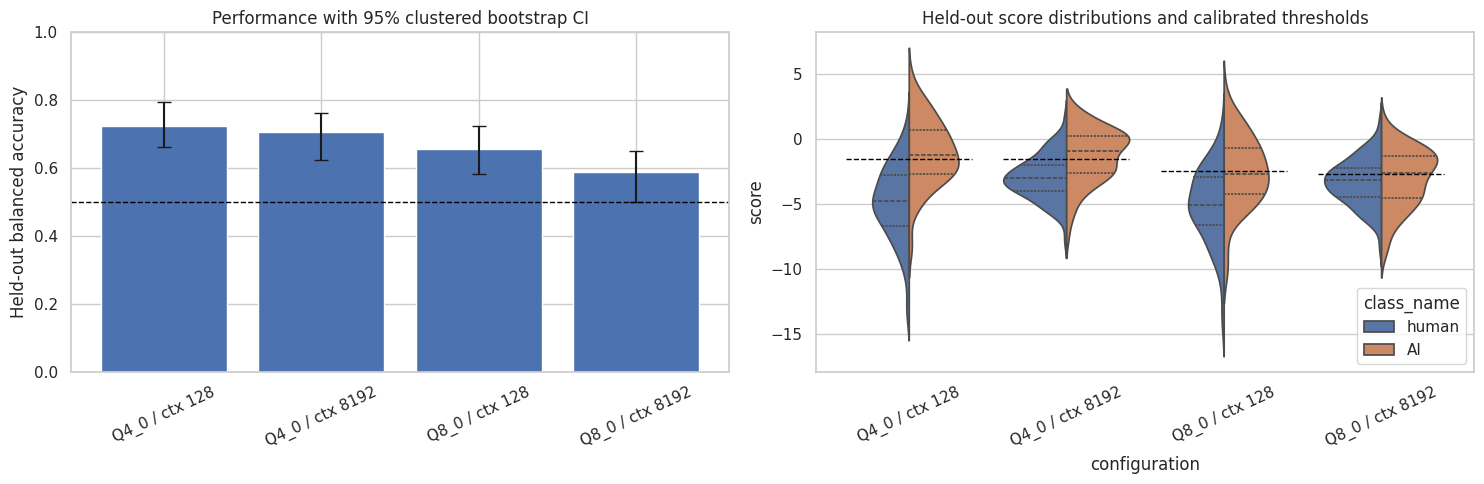

In [10]:
threshold_lookup = results.set_index(
    ["model_id", "context_length"]
).threshold.to_dict()
evaluation_scores = scores[scores.partition == "evaluation"].copy()
evaluation_scores["threshold"] = [
    threshold_lookup[(model_id, context)]
    for model_id, context in zip(
        evaluation_scores.model_id,
        evaluation_scores.context_length,
    )
]
evaluation_scores["prediction"] = (
    evaluation_scores.score >= evaluation_scores.threshold
).astype(int)

length_rows = []
for (model_id, model_label, context, band), group in evaluation_scores.groupby(
    ["model_id", "model_label", "context_length", "length_band"]
):
    threshold = threshold_lookup[(model_id, context)]
    length_rows.append(
        {
            "model_id": model_id,
            "model_label": model_label,
            "context_length": context,
            "length_band": band,
            "n": len(group),
            **classification_metrics(group.label, group.score, threshold),
        }
    )
length_metrics = pd.DataFrame(length_rows)
display(
    length_metrics[
        [
            "model_label", "context_length", "length_band", "n",
            "balanced_accuracy", "auroc", "recall", "specificity",
        ]
    ].style.format(precision=3)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_results = results.copy()
plot_results["configuration"] = (
    plot_results.model_label.str.replace("Llama 3 8B ", "", regex=False)
    + " / ctx "
    + plot_results.context_length.astype(str)
)
axes[0].bar(
    plot_results.configuration,
    plot_results.balanced_accuracy,
    yerr=[
        plot_results.balanced_accuracy - plot_results.balanced_accuracy_ci_low,
        plot_results.balanced_accuracy_ci_high - plot_results.balanced_accuracy,
    ],
    capsize=5,
)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Held-out balanced accuracy")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_title("Performance with 95% clustered bootstrap CI")

sns.violinplot(
    data=evaluation_scores.assign(
        configuration=lambda frame: (
            frame.precision
            + " / ctx "
            + frame.context_length.astype(str)
        ),
        class_name=lambda frame: frame.label.map({0: "human", 1: "AI"}),
    ),
    x="configuration",
    y="score",
    hue="class_name",
    split=True,
    inner="quart",
    ax=axes[1],
)
for position, row in plot_results.reset_index(drop=True).iterrows():
    axes[1].hlines(
        row.threshold,
        position - 0.4,
        position + 0.4,
        colors="black",
        linestyles="--",
        linewidth=1,
    )
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_title("Held-out score distributions and calibrated thresholds")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q4_q8_context_results.png", dpi=180, bbox_inches="tight")
plt.show()


## Export reproducible artifacts

Every output lives in a run-specific directory, preventing stale files from
older sample sizes from being mixed into the archive.


In [11]:
samples.to_csv(OUTPUT_DIR / "paired_samples.csv", index=False)
scores.to_csv(OUTPUT_DIR / "all_scores.csv", index=False)
results.to_csv(OUTPUT_DIR / "thresholds_and_metrics.csv", index=False)
bootstrap.to_csv(OUTPUT_DIR / "metric_bootstrap.csv", index=False)
comparisons.to_csv(OUTPUT_DIR / "primary_comparisons.csv", index=False)
comparison_bootstrap.to_csv(
    OUTPUT_DIR / "comparison_bootstrap.csv",
    index=False,
)
length_metrics.to_csv(OUTPUT_DIR / "metrics_by_text_length.csv", index=False)

metadata = {
    "run_id": RUN_ID,
    "seed": SEED,
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "dataset_license": DATASET_LICENSE,
    "calibration_split": CALIBRATION_SPLIT,
    "evaluation_split": EVALUATION_SPLIT,
    "calibration_texts": int(
        (samples.partition == "calibration").sum()
    ),
    "evaluation_texts": int(
        (samples.partition == "evaluation").sum()
    ),
    "contexts": CONTEXT_LENGTHS,
    "models": [asdict(model) for model in MODELS],
    "token_range": [MIN_TEXT_TOKENS, MAX_TEXT_TOKENS],
    "bootstrap_repeats": BOOTSTRAP_REPEATS,
    "comparison_ci_level": COMPARISON_CI_LEVEL,
    "python": platform.python_version(),
}
with open(OUTPUT_DIR / "run_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2)

archive = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
print("Artifacts:", OUTPUT_DIR.resolve())
print("ZIP:", archive)
print(sorted(path.name for path in OUTPUT_DIR.iterdir()))

if DELETE_MODEL_AFTER_RUN:
    for path in list(staged_model_paths):
        if path.exists():
            path.unlink()
            print("Deleted staged model:", path.name)
        staged_model_paths.discard(path)


Artifacts: /content/detectllama_q4_q8/q4-q8_ctx128-8192_953b44b7_seed20260731_cal80_eval160
ZIP: /content/detectllama_q4_q8/q4-q8_ctx128-8192_953b44b7_seed20260731_cal80_eval160.zip
['all_scores.csv', 'comparison_bootstrap.csv', 'metric_bootstrap.csv', 'metrics_by_text_length.csv', 'paired_samples.csv', 'primary_comparisons.csv', 'q4_q8_context_results.png', 'run_metadata.json', 'scores_base_q4_0_ctx128-8192.csv', 'scores_base_q8_0_ctx128-8192.csv', 'thresholds_and_metrics.csv']


## Interpretation checklist

- Treat prompt pairs, not individual AI variants, as independent units.
- Use `thresholds_and_metrics.csv` for per-configuration thresholds and
  held-out results.
- Use `primary_comparisons.csv` for the four preregistered paired comparisons.
- A confidence interval crossing zero is inconclusive, not evidence of
  equivalence.
- Thresholds are specific to the exact GGUF, context, tokenizer, dataset
  revision, seed, and length distribution.
- `score >= threshold` means AI-like; `score < threshold` means human-like.
- These thresholds are decision boundaries, not AI probabilities.
- Length-band results are exploratory because their effective sample sizes are
  smaller.
- The AI class contains only the dataset's direct Claude (`0`) and GPT (`1`)
  labels; prompt-engineered labels `2–5` are excluded. Results do not
  automatically generalize to other languages, domains, generators, edited
  text, or mixed-authorship documents.
- Increase `CALIBRATION_TEXTS`, `EVALUATION_TEXTS`, and
  `BOOTSTRAP_REPEATS` only when the available compute budget permits it.
